# *Flood Water Segmentation from UAV Images using Deep Learning*

In [ ]:
# Colab-specific: install extra libs
!pip install -q segmentation-models-pytorch timm albumentations==1.3.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Projects /flood_dataset.zip"
extract_dir = "/content/flood_dataset"   # final folder after extraction

# Create the folder if not exists
os.makedirs(extract_dir, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted to:", extract_dir)
print(os.listdir(extract_dir))


Extracted to: /content/flood_dataset
['metadata.csv', 'Mask', 'Image']


In [ ]:
DATA_DIR = "/content/drive/MyDrive/Projects /flood_dataset.zip"

IMAGE_DIR = DATA_DIR + "/Image"
MASK_DIR  = DATA_DIR + "/Mask"
CSV_PATH  = DATA_DIR + "/metadata.csv"

print(IMAGE_DIR)
print(MASK_DIR)
print(CSV_PATH)


/content/drive/MyDrive/Projects /flood_dataset.zip/Image
/content/drive/MyDrive/Projects /flood_dataset.zip/Mask
/content/drive/MyDrive/Projects /flood_dataset.zip/metadata.csv


In [ ]:
import os

DATA_DIR  = "/content/flood_dataset"      # <- extracted folder
IMAGE_DIR = os.path.join(DATA_DIR, "Image")
MASK_DIR  = os.path.join(DATA_DIR, "Mask")
CSV_PATH  = os.path.join(DATA_DIR, "metadata.csv")

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)
print("CSV_PATH :", CSV_PATH)
print("Images sample:", os.listdir(IMAGE_DIR)[:5])
print("Masks sample :", os.listdir(MASK_DIR)[:5])


IMAGE_DIR: /content/flood_dataset/Image
MASK_DIR : /content/flood_dataset/Mask
CSV_PATH : /content/flood_dataset/metadata.csv
Images sample: ['20.jpg', '1068.jpg', '48.jpg', '11.jpg', '3008.jpg']
Masks sample : ['3008.png', '3097.png', '3080.png', '3009.png', '3065.png']


# Import **Libraries**

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Transformations

In [ ]:
df = pd.read_csv(CSV_PATH)
print(df.head())
print(df.columns)


   Image   Mask
0  0.jpg  0.png
1  1.jpg  1.png
2  2.jpg  2.png
3  3.jpg  3.png
4  4.jpg  4.png
Index(['Image', 'Mask'], dtype='object')


In [ ]:
df = pd.read_csv(CSV_PATH)
print(df.head())
print("Columns:", df.columns.tolist())

# assume first col = image filename, second col = mask filename
IMG_COL  = df.columns[0]
MASK_COL = df.columns[1]

print("Using image column :", IMG_COL)
print("Using mask  column :", MASK_COL)


   Image   Mask
0  0.jpg  0.png
1  1.jpg  1.png
2  2.jpg  2.png
3  3.jpg  3.png
4  4.jpg  4.png
Columns: ['Image', 'Mask']
Using image column : Image
Using mask  column : Mask


In [ ]:
IMAGE_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


In [ ]:
class FloodSegmentationDataset(Dataset):
    def __init__(self, df, image_dir, mask_dir, img_col, mask_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.img_col   = img_col   # column name for image filename
        self.mask_col  = mask_col  # column name for mask filename
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_name = row[self.img_col]
        mask_name  = row[self.mask_col]

        image_path = os.path.join(self.image_dir, image_name)
        mask_path  = os.path.join(self.mask_dir,  mask_name)

        image = np.array(Image.open(image_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"))

        mask = (mask > 0).astype('float32')

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']

        mask = mask.unsqueeze(0)   # [H,W] -> [1,H,W]

        return image, mask


In [ ]:
from PIL import Image
import os

bad_indices = []

for idx, row in df.iterrows():
    img_name  = row[IMG_COL]
    mask_name = row[MASK_COL]

    img_path  = os.path.join(IMAGE_DIR, img_name)
    mask_path = os.path.join(MASK_DIR, mask_name)

    try:
        img  = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
    except Exception as e:
        print(f"Error opening files at index {idx}: {img_name}, {mask_name} -> {e}")
        bad_indices.append(idx)
        continue

    if img.size != mask.size:
        print(f"Size mismatch at index {idx}:")
        print("  image:", img_name, "size:", img.size)
        print("  mask :", mask_name, "size:", mask.size)
        bad_indices.append(idx)

print("Total bad samples:", len(bad_indices))


Size mismatch at index 14:
  image: 14.jpg size: (1900, 1425)
  mask : 14.png size: (1024, 630)
Size mismatch at index 15:
  image: 15.jpg size: (1024, 630)
  mask : 15.png size: (1900, 1425)
Size mismatch at index 101:
  image: 2052.jpg size: (1012, 490)
  mask : 2052.png size: (1200, 800)
Size mismatch at index 102:
  image: 2053.jpg size: (1200, 800)
  mask : 2053.png size: (1012, 490)
Size mismatch at index 162:
  image: 3059.jpg size: (650, 400)
  mask : 3059.png size: (1920, 1005)
Size mismatch at index 263:
  image: 1061.jpg size: (660, 440)
  mask : 1061.png size: (700, 389)
Size mismatch at index 281:
  image: 1079.jpg size: (1024, 682)
  mask : 1079.png size: (759, 422)
Total bad samples: 7


In [ ]:
df_clean = df.drop(index=bad_indices).reset_index(drop=True)
print("Original samples:", len(df))
print("Clean samples   :", len(df_clean))


Original samples: 290
Clean samples   : 283


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_clean, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 226 Val: 28 Test: 29


# Train/Val/Test Split & DataLoaders

In [ ]:
train_dataset = FloodSegmentationDataset(train_df, IMAGE_DIR, MASK_DIR, IMG_COL, MASK_COL, transform=train_transform)
val_dataset   = FloodSegmentationDataset(val_df,   IMAGE_DIR, MASK_DIR, IMG_COL, MASK_COL, transform=val_transform)
test_dataset  = FloodSegmentationDataset(test_df,  IMAGE_DIR, MASK_DIR, IMG_COL, MASK_COL, transform=val_transform)

BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=0)


Model: U-Net with Pretrained Encoder

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [ ]:
model = smp.Unet(
    encoder_name="resnet34",        # choose encoder
    encoder_weights="imagenet",     # use ImageNet pre-training
    in_channels=3,
    classes=1,                      # binary mask
    activation=None                 # we'll apply sigmoid in loss/metrics
)

model = model.to(DEVICE)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

# Loss Function & Metrics

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1.0):
    """
    pred: logits (before sigmoid), shape [B,1,H,W]
    target: [B,1,H,W]
    """
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice

def bce_dice_loss(pred, target):
    return bce_loss(pred, target) + dice_loss(pred, target)


In [ ]:
def iou_score(pred, target, threshold=0.5, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def dice_score(pred, target, threshold=0.5, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    dice = (2*intersection + eps) / (pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps)
    return dice.mean().item()


# Training & Validation Loop

In [ ]:
from tqdm.auto import tqdm

EPOCHS = 25
LEARNING_RATE = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_iou = 0.0
history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}


In [ ]:
for epoch in range(1, EPOCHS+1):
    # --------- TRAIN ---------
    model.train()
    train_losses = []

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} - Train"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = bce_dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    # --------- VALIDATION ---------
    model.eval()
    val_losses = []
    val_ious = []
    val_dices = []

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} - Val"):
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)

            outputs = model(images)
            loss = bce_dice_loss(outputs, masks)

            val_losses.append(loss.item())
            val_ious.append(iou_score(outputs, masks))
            val_dices.append(dice_score(outputs, masks))

    avg_val_loss = np.mean(val_losses)
    avg_val_iou  = np.mean(val_ious)
    avg_val_dice = np.mean(val_dices)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_iou"].append(avg_val_iou)
    history["val_dice"].append(avg_val_dice)

    print(f"\nEpoch {epoch}/{EPOCHS}: "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val IoU: {avg_val_iou:.4f} | "
          f"Val Dice: {avg_val_dice:.4f}")

    # save best model
    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model updated.")


Epoch 1/25 - Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 1/25 - Val:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 1/25: Train Loss: 0.9799 | Val Loss: 0.7785 | Val IoU: 0.5957 | Val Dice: 0.7280
✅ Best model updated.


Epoch 2/25 - Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 2/25 - Val:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 24/25 - Val:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 24/25: Train Loss: 0.3369 | Val Loss: 0.3855 | Val IoU: 0.7737 | Val Dice: 0.8628


Epoch 25/25 - Train:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 25/25 - Val:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 25/25: Train Loss: 0.3216 | Val Loss: 0.3891 | Val IoU: 0.7748 | Val Dice: 0.8618


# Plot Training Curves

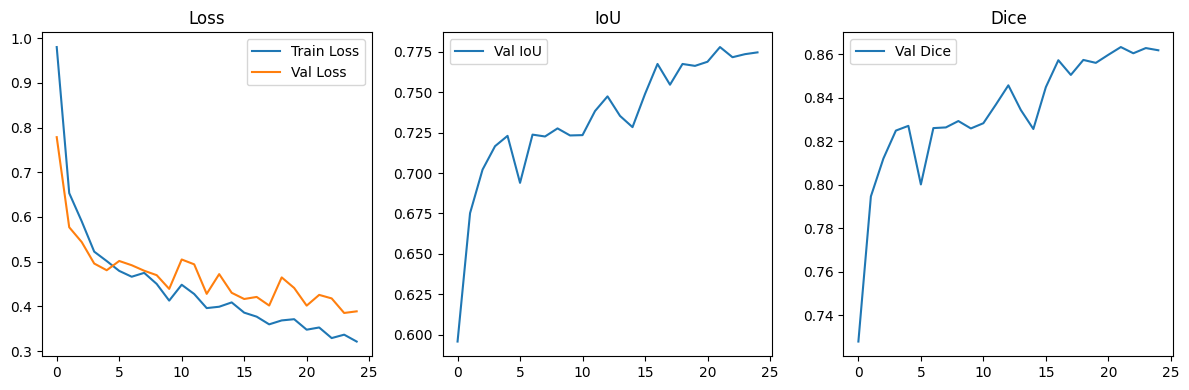

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,3,2)
plt.plot(history["val_iou"], label="Val IoU")
plt.legend()
plt.title("IoU")

plt.subplot(1,3,3)
plt.plot(history["val_dice"], label="Val Dice")
plt.legend()
plt.title("Dice")

plt.tight_layout()
plt.show()


# Saving the Model

In [ ]:
# path in your Drive (change folder if you want)
save_path = "/content/drive/MyDrive/Projects /flood_unet_best.pth"

torch.save(model.state_dict(), save_path)
print("Model saved to:", save_path)


Model saved to: /content/drive/MyDrive/Projects /flood_unet_best.pth


# Load Best Model & Evaluate on Test Set

In [ ]:
# Load best model weights
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

test_ious = []
test_dices = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Test Evaluation"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        outputs = model(images)
        test_ious.append(iou_score(outputs, masks))
        test_dices.append(dice_score(outputs, masks))

print(f"Test IoU:  {np.mean(test_ious):.4f}")
print(f"Test Dice: {np.mean(test_dices):.4f}")


Test Evaluation:   0%|          | 0/29 [00:00<?, ?it/s]

Test IoU:  0.7941
Test Dice: 0.8763


# Visualize Predictions (Original vs GT vs Pred)

In [ ]:
def show_sample(image, gt_mask, pred_mask, threshold=0.5):
    """
    image: tensor [3,H,W]
    gt_mask: tensor [1,H,W]
    pred_mask: tensor [1,H,W] logits
    """
    image_np = image.cpu().permute(1,2,0).numpy()
    image_np = (image_np * np.array([0.229, 0.224, 0.225]) +
                np.array([0.485, 0.456, 0.406]))  # unnormalize
    image_np = np.clip(image_np, 0, 1)

    gt = gt_mask.cpu().squeeze().numpy()
    pred = torch.sigmoid(pred_mask).cpu().squeeze().numpy()
    pred_bin = (pred > threshold).astype(np.float32)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gt, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()


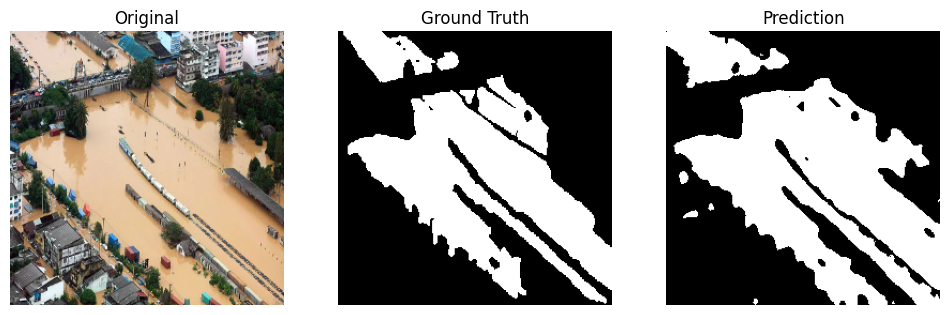

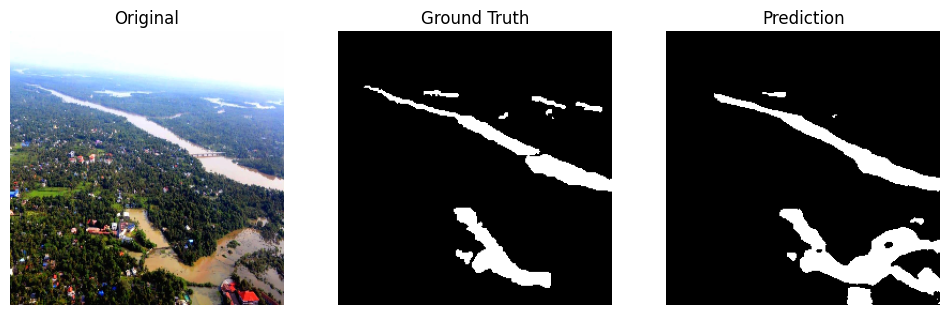

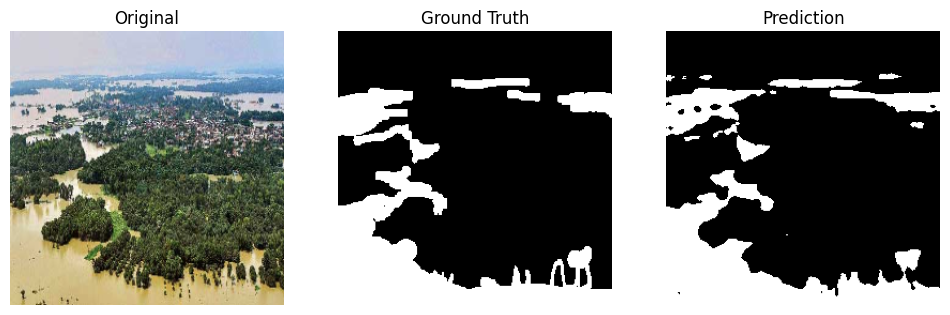

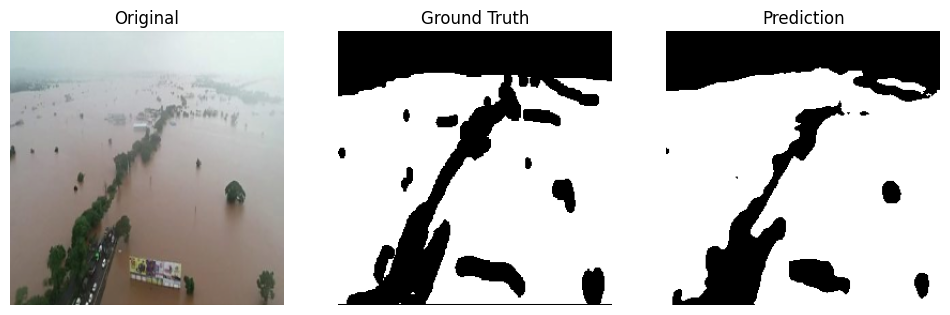

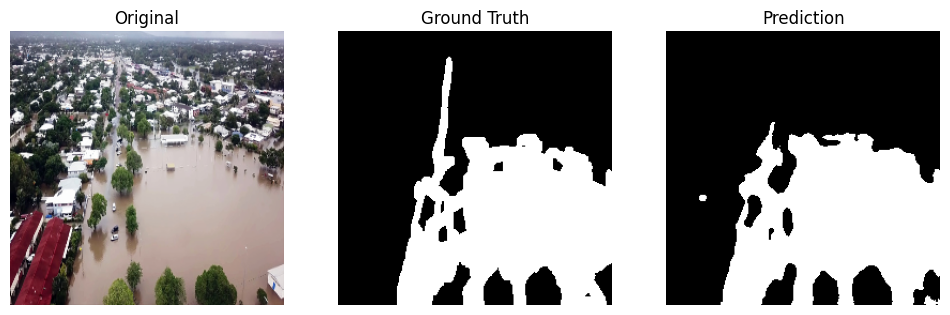

In [ ]:
# Show a few random test samples
model.eval()
samples_to_show = 5

with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        if i >= samples_to_show:
            break
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        outputs = model(images)

        show_sample(images[0], masks[0], outputs[0])


# Flooded Area Percentage (Practical Metric)

In [ ]:
def compute_flood_percentage(pred_mask, threshold=0.5):
    """
    pred_mask: logits tensor [1,H,W]
    """
    probs = torch.sigmoid(pred_mask)
    bin_mask = (probs > threshold).float()
    flood_pixels = bin_mask.sum().item()
    total_pixels = bin_mask.numel()
    return (flood_pixels / total_pixels) * 100.0


In [ ]:
model.eval()
image_ids = []
flood_percentages = []

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(DEVICE)
        outputs = model(images)

        perc = compute_flood_percentage(outputs[0])
        flood_percentages.append(perc)

        # use the actual image column name
        image_ids.append(test_df.iloc[idx][IMG_COL])

flood_stats = pd.DataFrame({
    "image_name": image_ids,            # you can call this column anything
    "flood_percentage": flood_percentages
})

flood_stats.head()


,image_name,flood_percentage
0,9.jpg,45.756531
1,1075.jpg,11.238098
2,1048.jpg,24.034119
3,1047.jpg,69.177246
4,2032.jpg,36.294556


In [ ]:
def risk_category(p):
    if p < 20:
        return "Low"
    elif p < 50:
        return "Medium"
    else:
        return "High"

flood_stats["risk_level"] = flood_stats["flood_percentage"].apply(risk_category)
flood_stats.head()


,image_name,flood_percentage,risk_level
0,9.jpg,45.756531,Medium
1,1075.jpg,11.238098,Low
2,1048.jpg,24.034119,Medium
3,1047.jpg,69.177246,High
4,2032.jpg,36.294556,Medium


# Future evaluation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1️⃣ Recreate the same architecture
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

# 2️⃣ Load your saved trained weights
save_path = "/content/drive/MyDrive/Projects /flood_unet_best.pth"
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.eval()


Mounted at /content/drive


ModuleNotFoundError: No module named 'segmentation_models_pytorch'